In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.ion()

In [3]:
plt.isinteractive()

True

# **Utilizing seaborn for advanced plotting**

In [4]:
fb_df = pd.read_csv(
    '../Datasets/fb_stock_prices_2018.csv',
    index_col='date',
    parse_dates=True
).convert_dtypes('numpy_nullable')

quake_df = pd.read_csv(
    '../Datasets/parsed.csv',
    dtype_backend='numpy_nullable'
)

## **Categorical data**

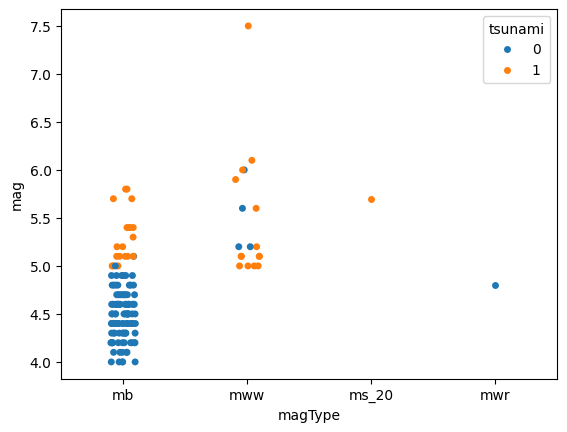

In [5]:
sns.stripplot(
    data=quake_df.query('parsed_place == "Indonesia"'),
    x='magType',
    y='mag',
    hue='tsunami'
)

plt.show()

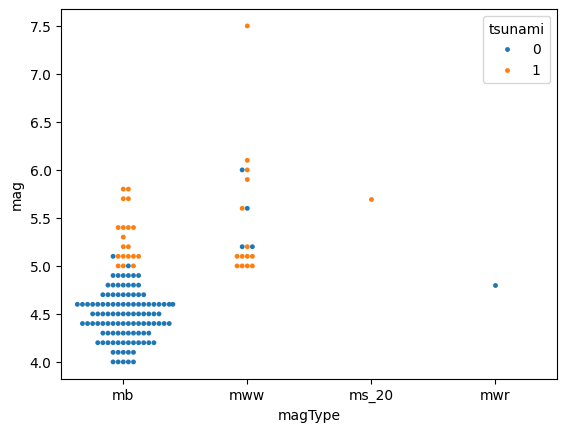

In [6]:
sns.swarmplot(
    data=quake_df.query('parsed_place == "Indonesia"'),
    x='magType',
    y='mag',
    hue='tsunami',
    size=3.5
)

plt.show()

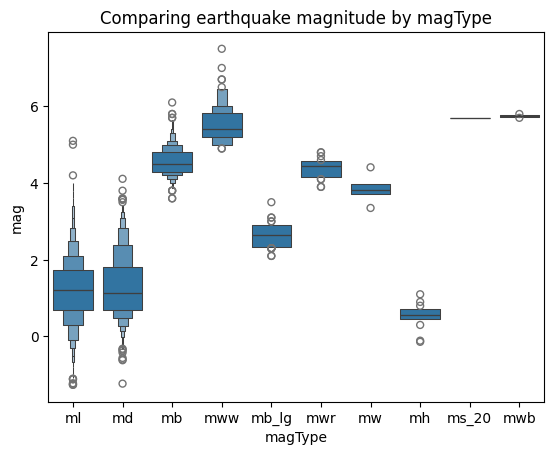

In [7]:
sns.boxenplot(
    data=quake_df[['magType', 'mag']], x='magType', y='mag'
)

plt.title('Comparing earthquake magnitude by magType')
plt.show()

> **Tip :** The enhanced box plot was introduced in the paper Letter-value plots: **Boxplots** for large data, by Heike Hofmann, Karen Kafadar, and Hadley Wickham, which can be found at https://vita.had.co.nz/papers/letter-value-plot.html.

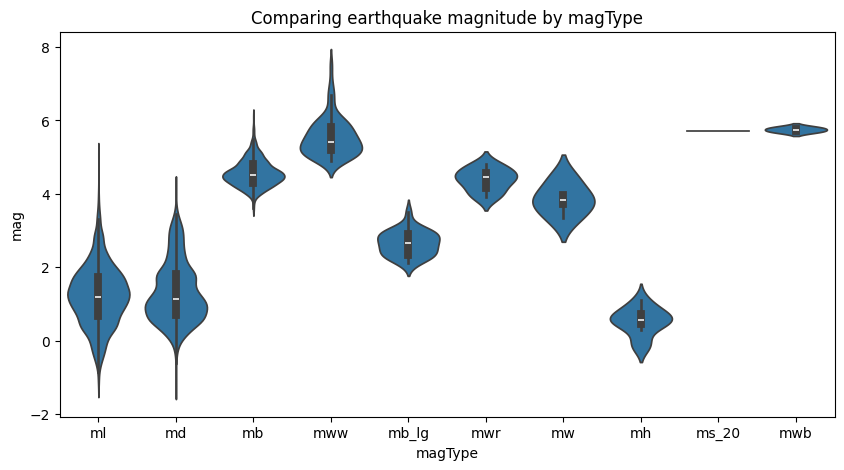

In [8]:
fig, axes = plt.subplots(figsize=(10, 5))
sns.violinplot(
    data=quake_df[['magType', 'mag']],
    ax=axes,
    x='magType', y='mag',
    density_norm='width' # all violins have same width
)

plt.title('Comparing earthquake magnitude by magType')
plt.show()

> Be sure to check out the **`countplot()`** and **`barplot()`** functions for variations on the bar plots we created with pandas in the previous chapter.

## **Correlations and heatmaps**

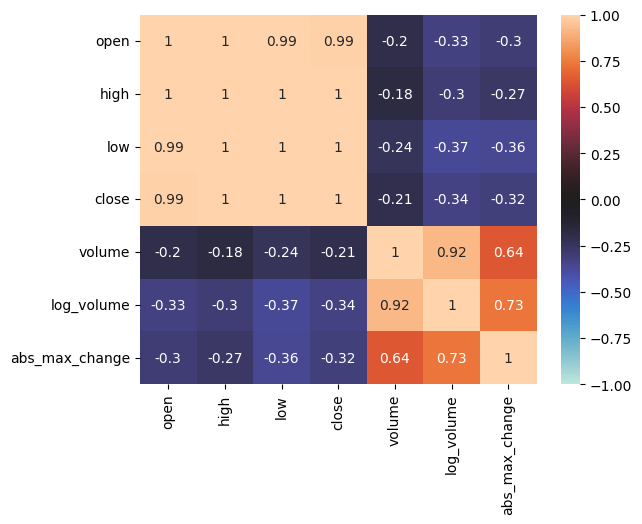

In [9]:
sns.heatmap(
    data=fb_df
        .sort_index()
        .assign(
            log_volume= np.log(fb_df.volume),
            abs_max_change= fb_df.high - fb_df.low
        ).corr(),
    annot=True,
    center=0,
    vmax=1,
    vmin=-1
)

plt.show()

> **Tip :** When using seaborn, we can still use functions from matplotlib, such as **`plt.savefig()`** and **`plt.tight_layout()`**. Note that if there are issues with **`plt.tight_layout()`**, pass **`bbox_inches='tight'`** to **`plt.savefig()`** instead.

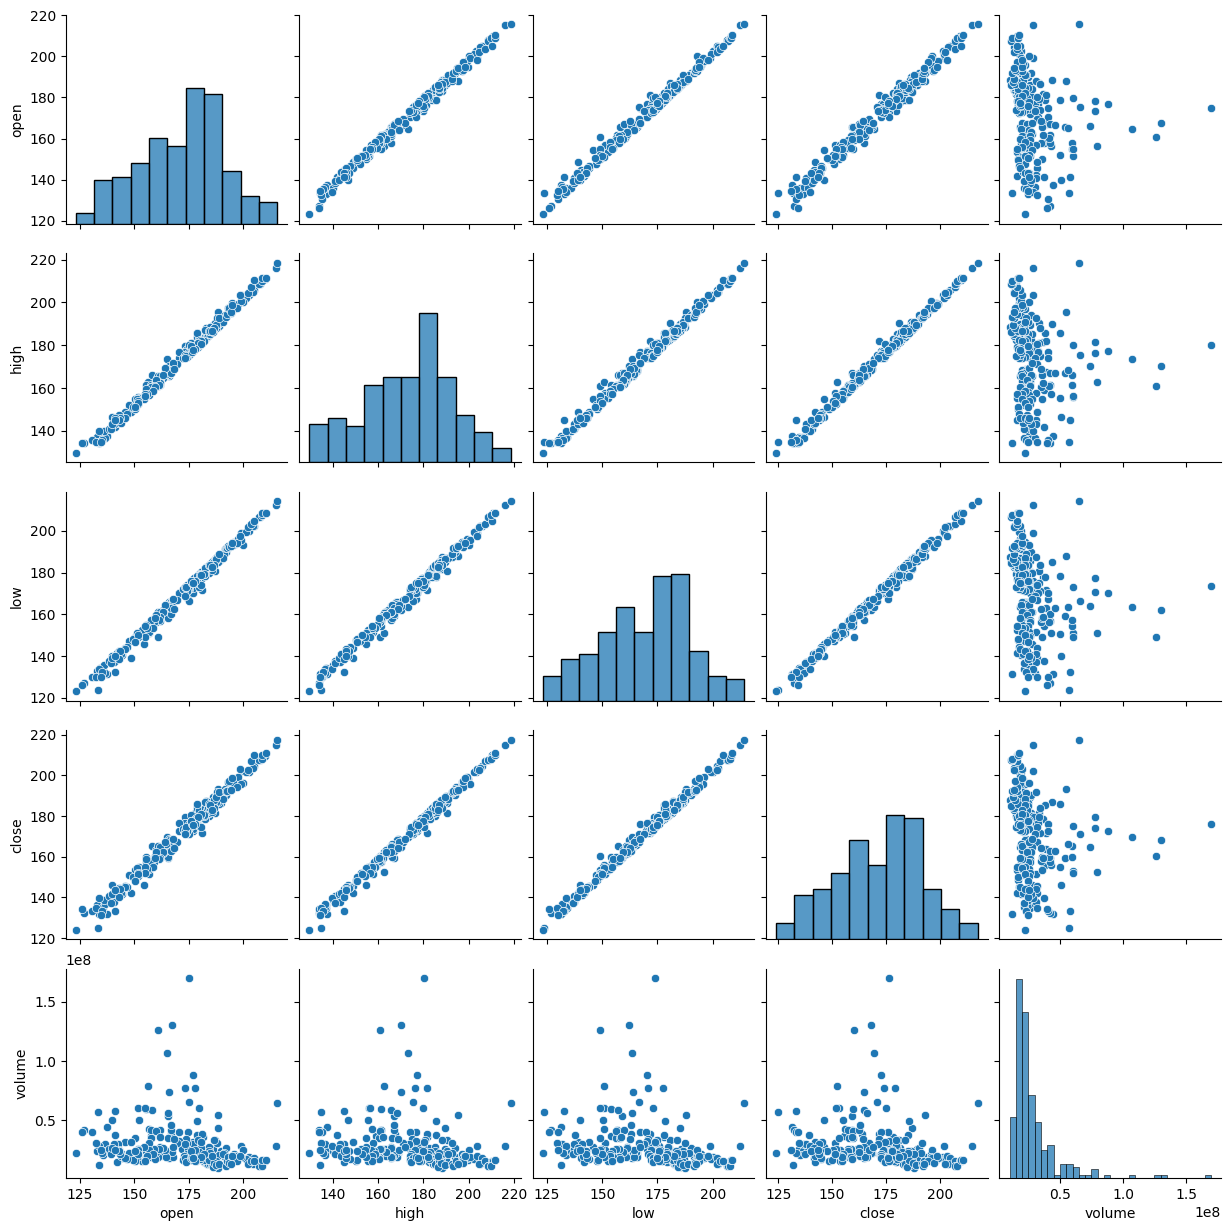

In [10]:
sns.pairplot(fb_df) # Alternative to scatter_matrix in .plotting module in pandas

plt.show()

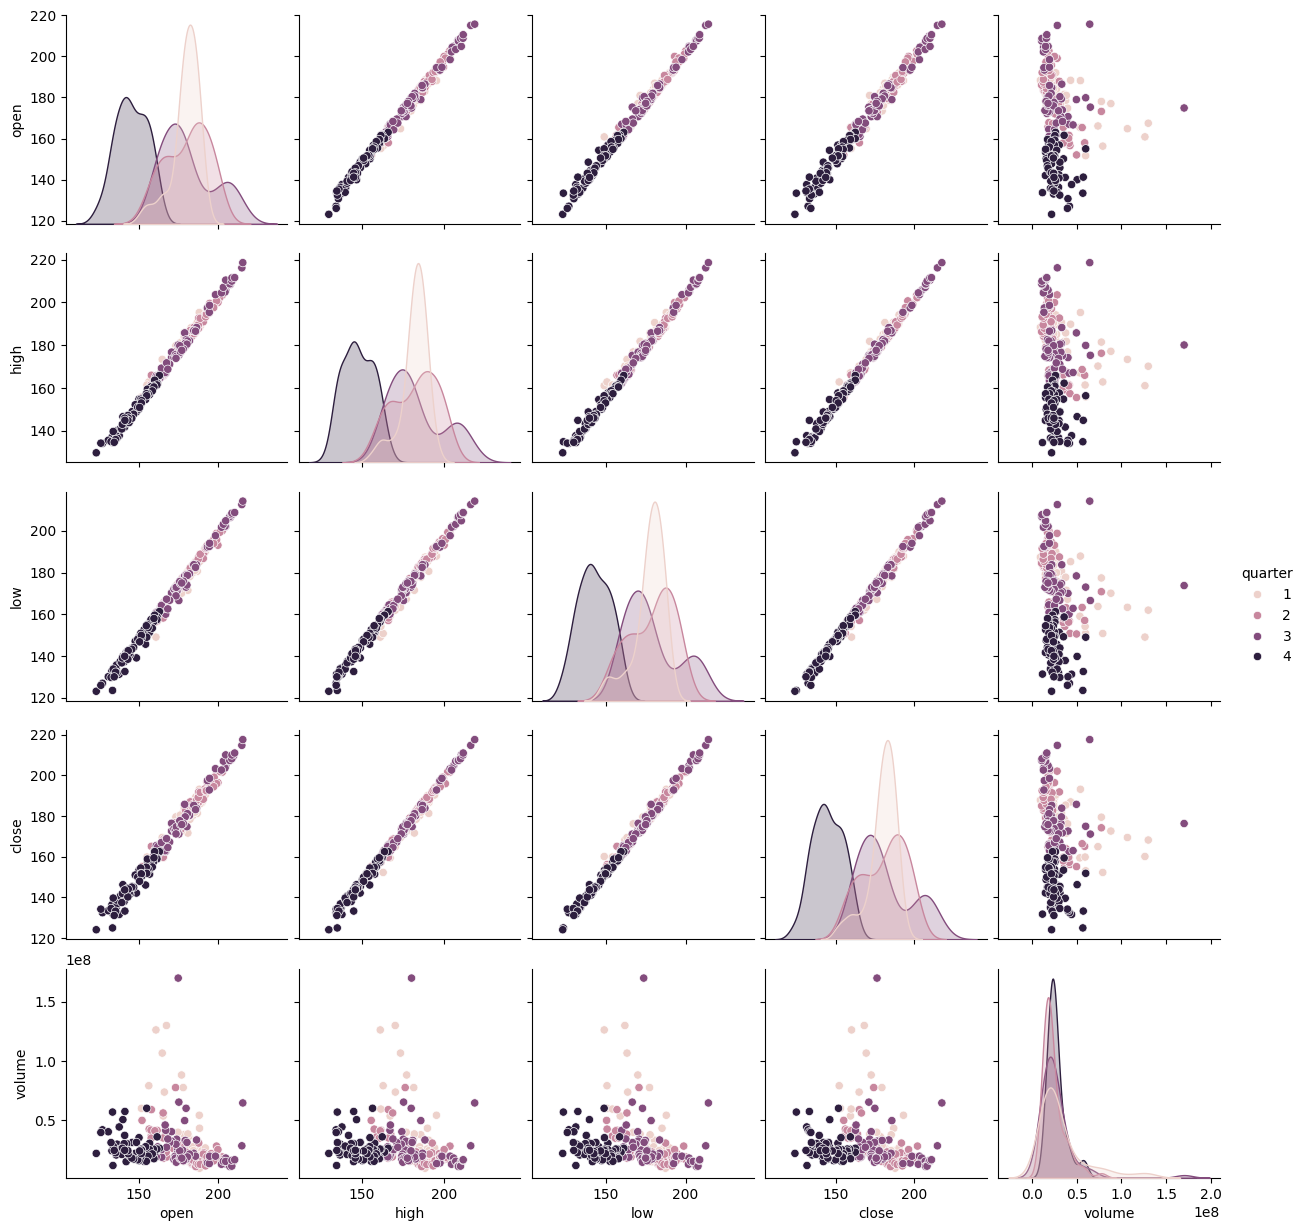

In [11]:
sns.pairplot(
    fb_df.assign(quarter= lambda x: x.index.quarter),
    diag_kind='kde', hue='quarter'
)

plt.show()

> **Tip :** We can also pass kind='reg' to pairplot() to show regression lines.

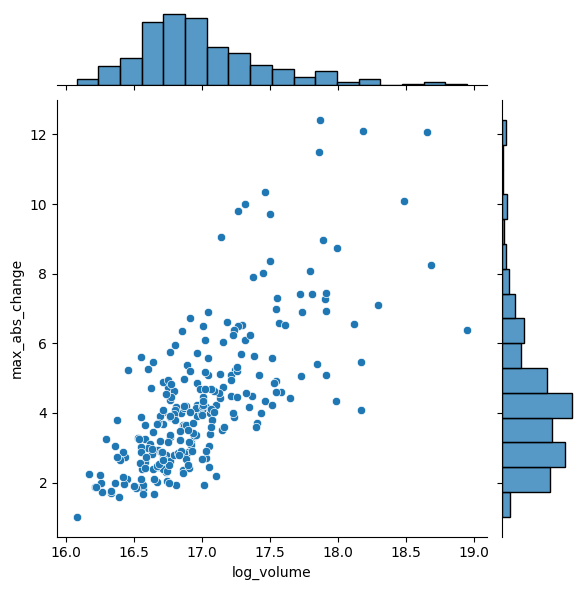

In [12]:
sns.jointplot(
    data=fb_df.assign(
        log_volume=np.log(fb_df.volume),
        max_abs_change=fb_df.high - fb_df.low
    ),
    x='log_volume', y='max_abs_change'
    
)

plt.show()

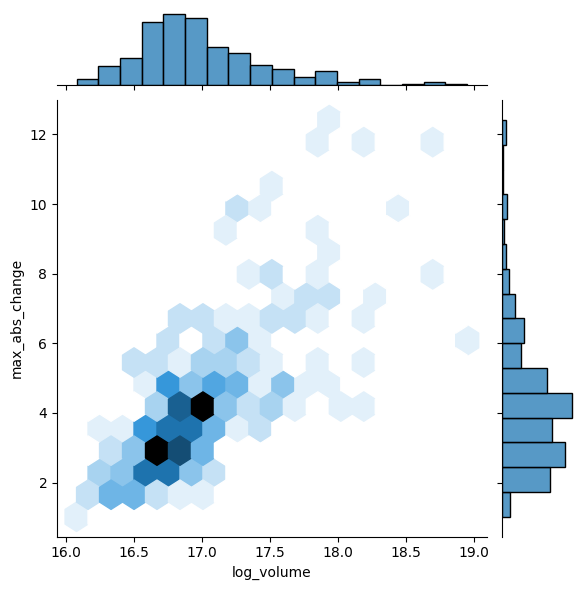

In [13]:
sns.jointplot(
    data=fb_df.assign(
        log_volume=np.log(fb_df.volume),
        max_abs_change= fb_df.high - fb_df.low
    ),
    x='log_volume', y='max_abs_change',
    kind='hex'
)

plt.show()

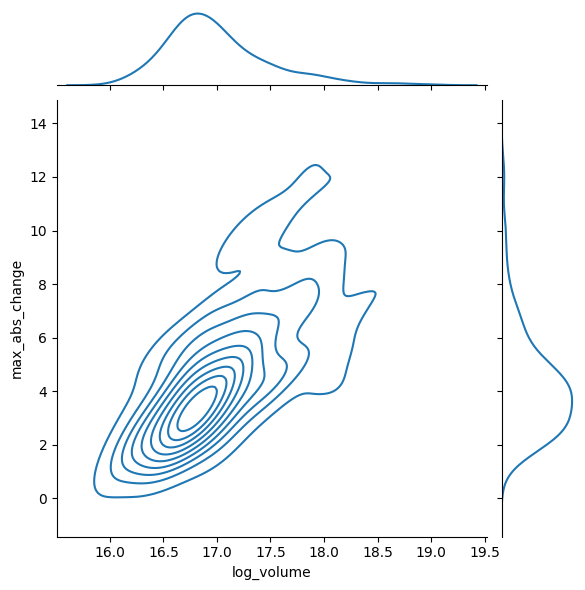

In [14]:
sns.jointplot(
    data=fb_df.assign(
        log_volume=np.log(fb_df.volume),
        max_abs_change= fb_df.high - fb_df.low
    ),
    x='log_volume', y='max_abs_change',
    kind='kde'
)

plt.show()

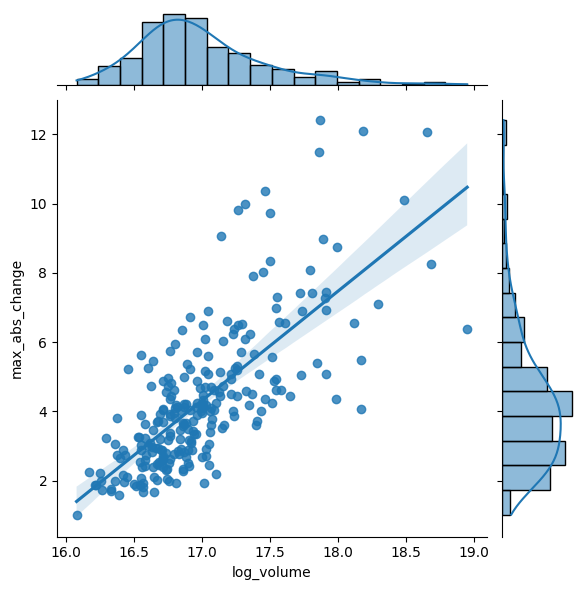

In [15]:
sns.jointplot(
    data=fb_df.assign(
        log_volume=np.log(fb_df.volume),
        max_abs_change= fb_df.high - fb_df.low
    ),
    x='log_volume', y='max_abs_change',
    kind='reg'
)

plt.show()

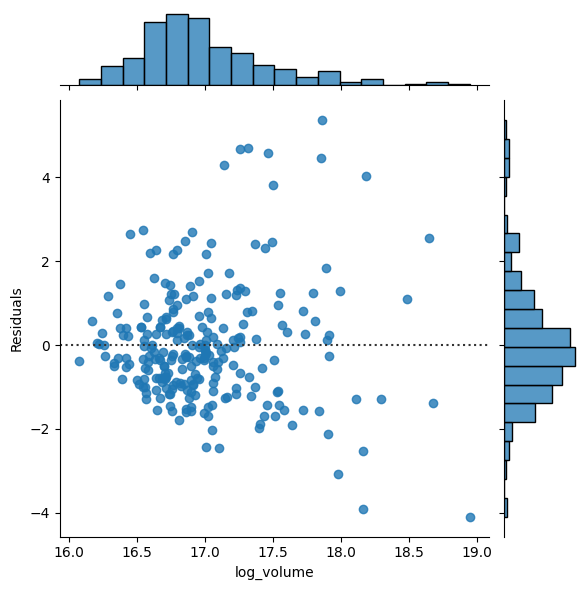

In [16]:
sns.jointplot(
    data=fb_df.assign(
        log_volume=np.log(fb_df.volume),
        max_abs_change= fb_df.high - fb_df.low
    ),
    x='log_volume', y='max_abs_change',
    kind='resid'
)

plt.ylabel('Residuals')
plt.show()

## **Regression plots**

In [17]:
fb_df_reg_data = fb_df.assign(
    log_volume=np.log(fb_df.volume),
    max_abs_change=fb_df.high - fb_df.low
).iloc[:, -2:]

fb_df_reg_data.head()

,log_volume,max_abs_change
date,,
2018-01-02,16.714286,4.03
2018-01-03,16.642029,3.45
2018-01-04,16.446024,2.1104
2018-01-05,16.423706,1.97
2018-01-08,16.705589,2.57


In [18]:
import itertools

In [19]:
iterator = itertools.repeat("I'am an iterator", 1)

In [20]:
for i in iterator:
    print(f'-->{i}')

-->I'am an iterator


In [21]:
for i in iterator:
    print(f'-->{i}') # it print it just once for all and don't for more because it exhausted

In [22]:
iterator

repeat("I'am an iterator", 0)

In [23]:
iterator = list(itertools.repeat("I'am an iterator", 1))

In [24]:
for i in iterator:
    print(f'-->{i}')

-->I'am an iterator


In [25]:
for i in iterator:
    print(f'-->{i}') # This prints again because it's an iterable

-->I'am an iterator


In [26]:
iterator

["I'am an iterator"]

In [27]:
def reg_resid_plots(data):
    """
    Using `seaborn`, plot the regression and residuals plots
    side-by-side for every permutation of 2 columns in data.
    
    Parameters:
    - data: A `pandas.DataFrame` object

    Returns:
    A matplotlib `Axes` object.
    """

    num_cols = data.shape[1]
    permutation_col = num_cols * (num_cols - 1)

    fig, ax = plt.subplots(nrows=permutation_col, ncols=2, figsize=(15, 8))

    for (x, y), axes, color in zip(itertools.permutations(data.columns, 2), ax, itertools.cycle(['royalblue', 'darkorange'])):
        for subplot, func in zip(axes, (sns.regplot, sns.residplot)):
            func(data=data, x=x, y=y, ax=subplot, color=color)
            if func == sns.residplot:
                subplot.set_ylabel('residuals')

    return fig.axes

[<Axes: xlabel='log_volume', ylabel='max_abs_change'>,
 <Axes: xlabel='log_volume', ylabel='residuals'>,
 <Axes: xlabel='max_abs_change', ylabel='log_volume'>,
 <Axes: xlabel='max_abs_change', ylabel='residuals'>]

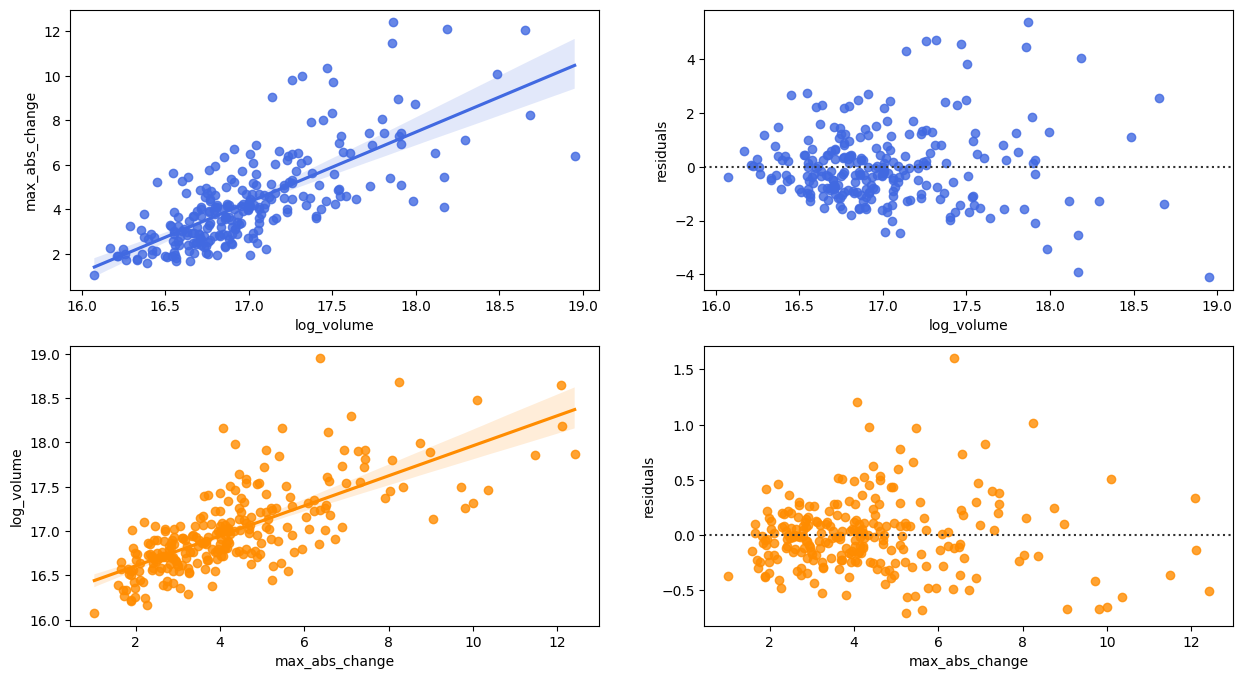

In [28]:
reg_resid_plots(fb_df_reg_data)

> **Tip :** The **`regplot()`** function supports polynomial and logistic regression through the **order** and **logistic** parameters, respectively.

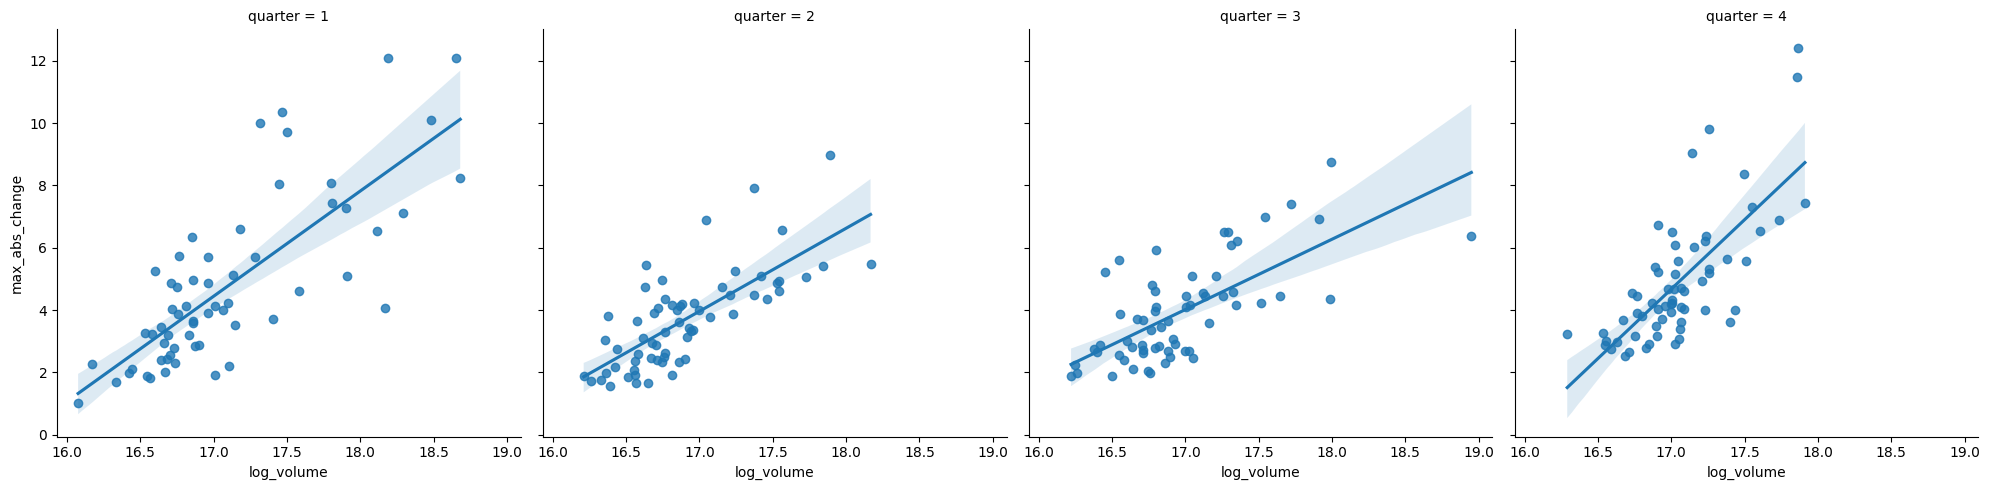

In [29]:
sns.lmplot(
    data=fb_df.assign(
        log_volume=np.log(fb_df.volume),
        max_abs_change=fb_df.high - fb_df.low,
        quarter= lambda x: x.index.quarter 
    ),
    x='log_volume', y='max_abs_change', col='quarter'
)

plt.show()

## **Faceting**

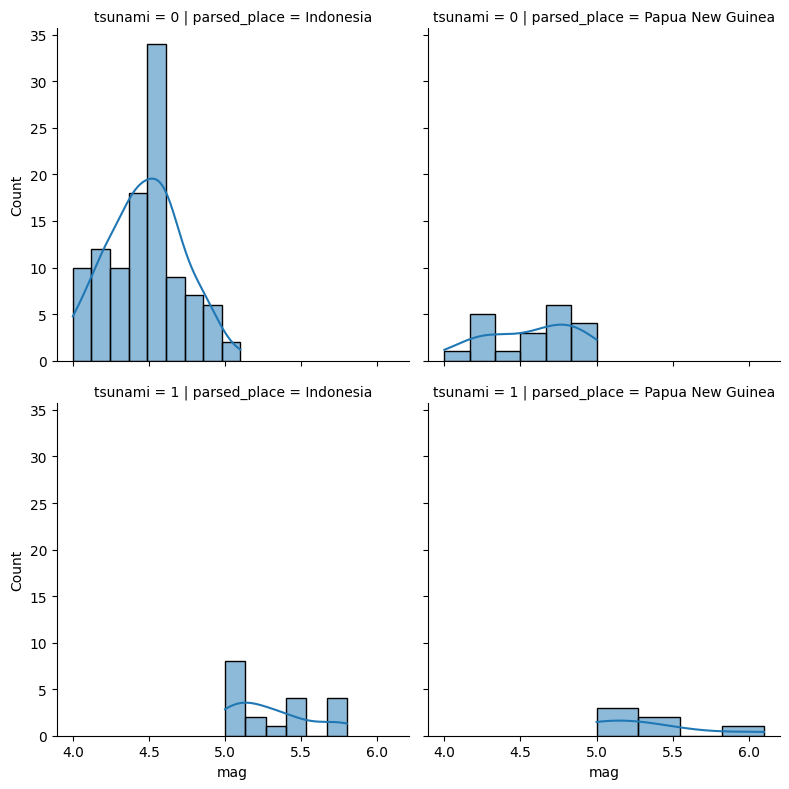

In [30]:
g = sns.FacetGrid(
    quake_df.query(
        'parsed_place.isin(["Indonesia", "Papua New Guinea"])'
        'and magType == "mb"'
    ),
    row='tsunami',
    col='parsed_place',
    height=4
)

g = g.map(sns.histplot, 'mag', kde=True)

# **Formatting plots with matplotlib**

In [31]:
covid_df = pd.read_csv(
    '../Datasets/covid19_cases.csv'
).assign(
    date= lambda x: pd.to_datetime(x.dateRep, format='%d/%m/%Y')
).set_index('date').replace(
    'United_States_of_America', 'USA'
).sort_index().convert_dtypes('numpy_nullable')['2020-01-18':'2020-09-18']

## **Titles and labels**

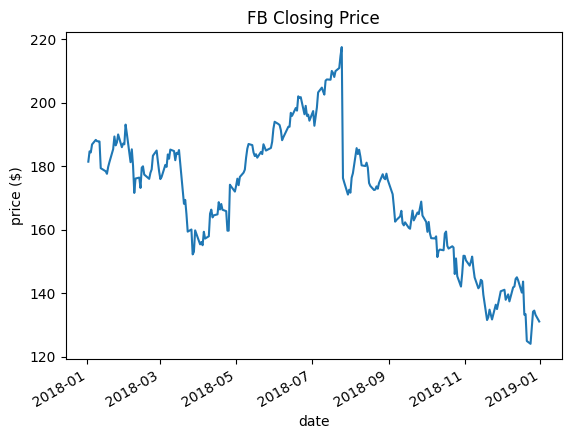

In [32]:
fb_df.close.plot()
plt.title('FB Closing Price')
plt.xlabel('date')
plt.ylabel('price ($)')

plt.show()

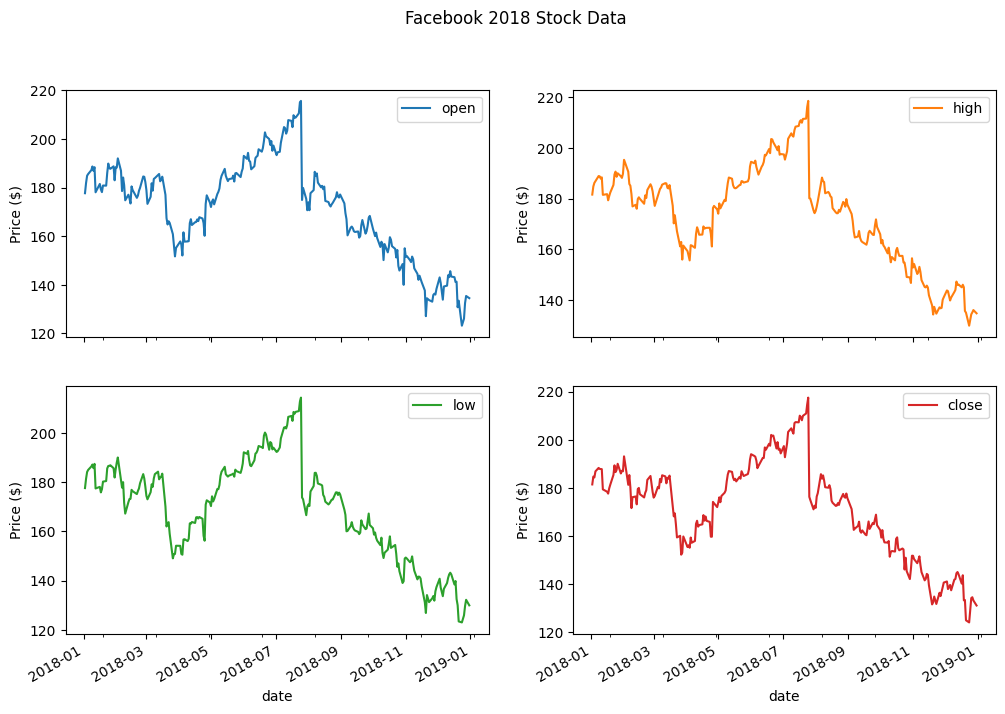

In [37]:
axes = fb_df.iloc[:, :4].plot(
    subplots=True, layout=(2, 2), figsize=(12, 8)
)
plt.suptitle('Facebook 2018 Stock Data')
for ax in axes.flatten():
    ax.set_ylabel('Price ($)')

plt.show()

## **Legends**

![Helpful parameters for legend formatting](../Images/Helpful_parameters_for_legend_formatting.png)

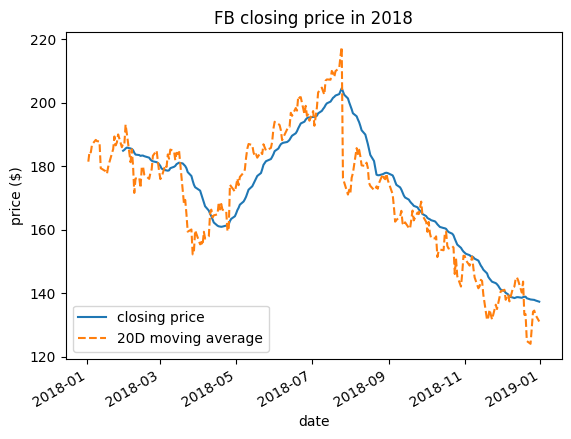

In [40]:
fb_df.assign(
    ma=lambda x: x.close.rolling(20).mean()
).plot(
    y=['ma', 'close'],
    label=['closing price', '20D moving average'],
    style=['-', '--'],
    title='FB closing price in 2018',
)

plt.legend(loc='lower left')
plt.ylabel('price ($)')
plt.show()

![Common legend locations](../Images/Common_legend_locations.png)

In [55]:
new_cases = covid_df.reset_index().pivot(
    index='date',
    columns='countriesAndTerritories' ,
    values='cases'
).fillna(0)

pct_new_case = new_cases.apply(
    lambda x: x / new_cases.apply('sum', axis=1), axis=0
)[
    ['Italy', 'China', 'Spain', 'USA', 'India', 'Brazil']
].sort_index(axis=1).fillna(0)

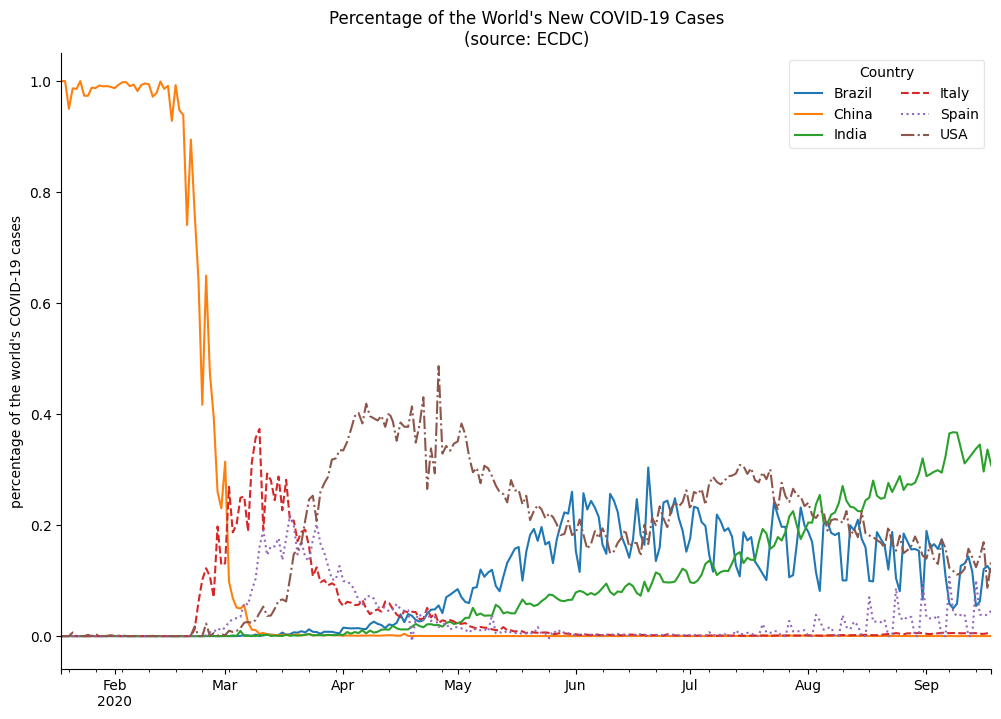

In [56]:
ax = pct_new_case.plot(
    figsize=(12, 8),
    style=['-'] * 3 + ['--', ':', '-.'],
    title='Percentage of the World\'s New COVID-19 Cases'
    '\n(source: ECDC)'
)

ax.legend(title='Country', framealpha=0.5, ncol=2)
ax.set_xlabel('')
ax.set_ylabel('percentage of the world\'s COVID-19 cases')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.show()

> **Tip :** Don't get overwhelmed trying to memorize all of the available options. It is easier if we don't try to learn every possible customization, but rather look up the functionality that matches what we have in mind for our visualization when needed.

## **Formatting axes**

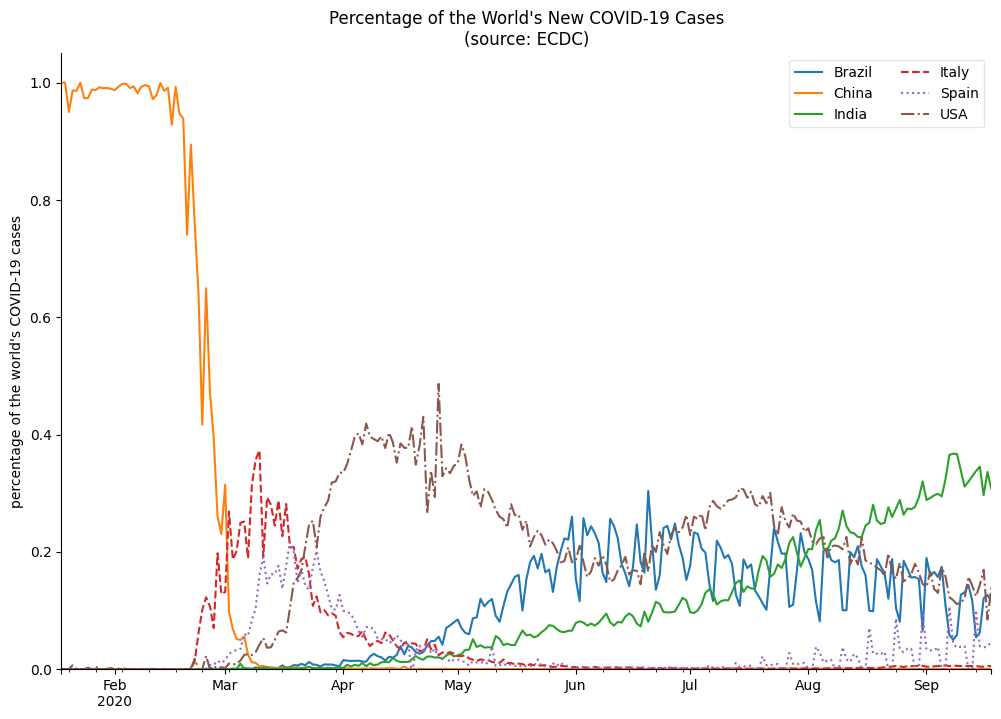

In [60]:
ax = pct_new_case.plot(
    figsize=(12, 8),
    style=['-'] * 3 + ['--', ':', '-.'],
    title='Percentage of the World\'s New COVID-19 Cases'
          '\n(source: ECDC)'
)

ax.legend(framealpha=0.5, ncol=2)
ax.set_xlabel('')
ax.set_ylabel('percentage of the world\'s COVID-19 cases')
ax.set_ylim(0, None)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.show()

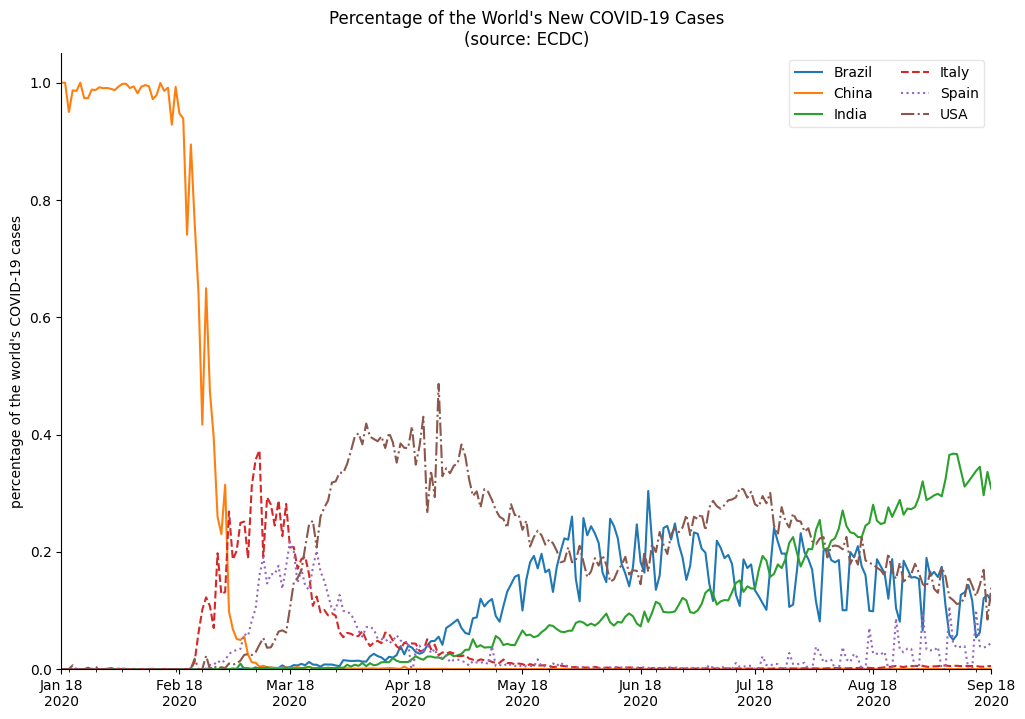

In [61]:
ax = pct_new_case.plot(
    figsize=(12, 8),
    style=['-'] * 3 + ['--', ':', '-.'],
    title='Percentage of the World\'s New COVID-19 Cases'
          '\n(source: ECDC)'
)

tick_locs = covid_df.index[covid_df.index.day == 18].unique()
tick_labels = [loc.strftime('%b %d\n%Y') for loc in tick_locs]
plt.xticks(tick_locs, tick_labels)

ax.legend(framealpha=0.5, ncol=2)
ax.set_xlabel('')
ax.set_ylabel('percentage of the world\'s COVID-19 cases')
ax.set_ylim(0, None)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.show()

In [62]:
from matplotlib.ticker import PercentFormatter

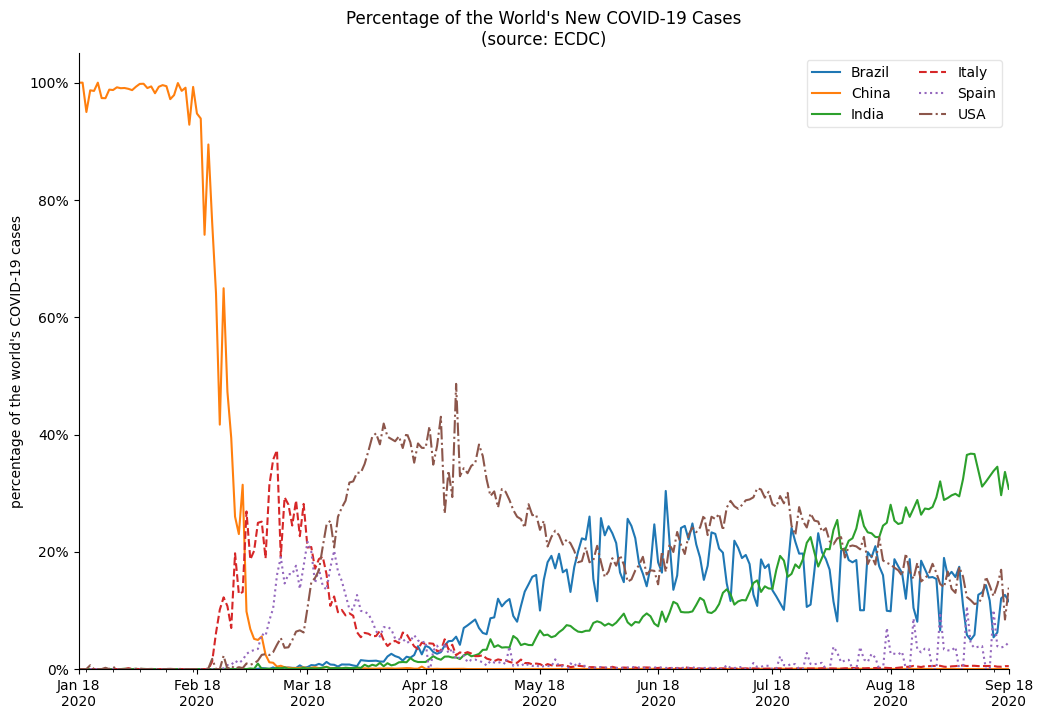

In [63]:
ax = pct_new_case.plot(
    figsize=(12, 8),
    style=['-'] * 3 + ['--', ':', '-.'],
    title='Percentage of the World\'s New COVID-19 Cases'
          '\n(source: ECDC)'
)

tick_locs = covid_df.index[covid_df.index.day == 18].unique()
tick_labels = [loc.strftime('%b %d\n%Y') for loc in tick_locs]
plt.xticks(tick_locs, tick_labels)

ax.legend(framealpha=0.5, ncol=2)
ax.set_xlabel('')
ax.set_ylabel('percentage of the world\'s COVID-19 cases')
ax.set_ylim(0, None)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.show()

In [64]:
from matplotlib.ticker import EngFormatter

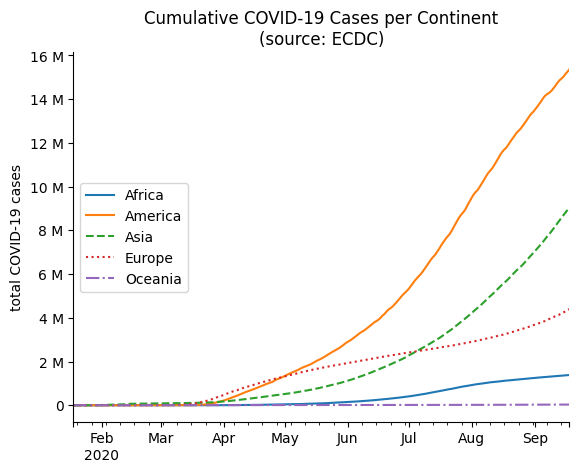

In [84]:
ax = covid_df.query('continentExp != "Other"').groupby(
    ['continentExp', pd.Grouper(freq='1D')]
).cases.sum().unstack(level=0).apply('cumsum').plot(
    style=['-', '-', '--', ':', '-.'],
    #figsize=(12, 8),
    title='Cumulative COVID-19 Cases per Continent'
          '\n(source: ECDC)'
)

ax.legend(title='', loc='center left')
ax.set(xlabel='', ylabel='total COVID-19 cases')
ax.yaxis.set_major_formatter(EngFormatter())

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.show()

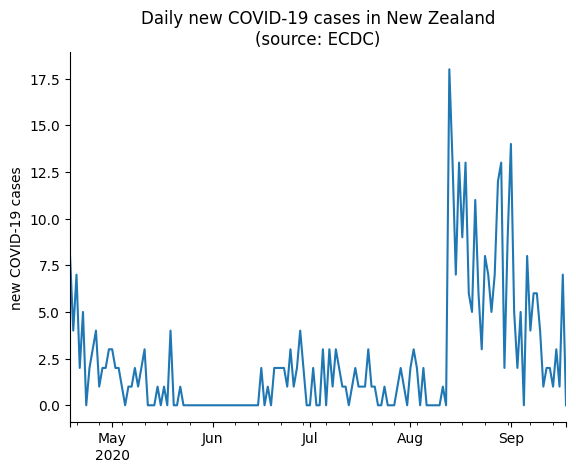

In [85]:
ax = new_cases.New_Zealand['2020-04-18':'2020-09-18'].plot(
    title='Daily new COVID-19 cases in New Zealand'
          '\n(source: ECDC)'
)
ax.set(xlabel='', ylabel='new COVID-19 cases')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.show()

In [86]:
from matplotlib.ticker import MultipleLocator

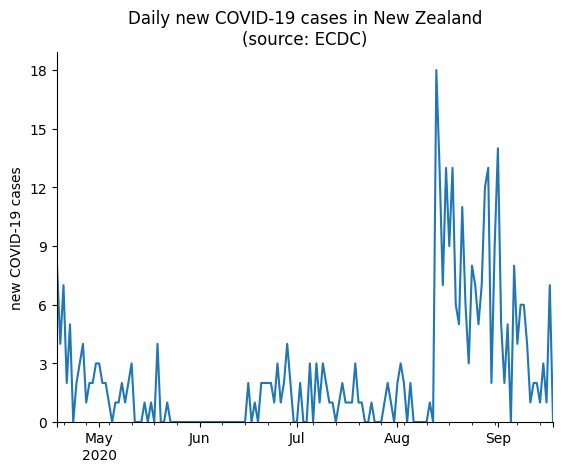

In [90]:
ax = new_cases.New_Zealand['2020-04-18':'2020-09-18'].plot(
    title='Daily new COVID-19 cases in New Zealand'
          '\n(source: ECDC)'
)
ax.set(xlabel='', ylabel='new COVID-19 cases')
ax.yaxis.set_major_locator(MultipleLocator(base=3))
plt.ylim(0, None)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.show()

# **Customizing visualizations**